In [203]:
# importamos las librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
from scipy.stats import entropy

In [204]:
df = pd.read_excel('../Actividad 2/Tensile_Properties_of_Sub-sized_Specimens.xlsx', header=1)

In [205]:
#Dimensiones del dataset
print(f"Dimensiones del dataset: {df.shape}")

Dimensiones del dataset: (1050, 55)


In [206]:
# Revisamos los nombres de las columnas
print("Nombres de las columnas:")
print(df.columns)

Nombres de las columnas:
Index(['Reference', 'Material', 'Material Group', 'C (wt.%)', 'Si (wt.%)',
       'Mn (wt.%)', 'P (wt.%)', 'S (wt.%)', 'Ni (wt.%)', 'Cr (wt.%)',
       'Mo (wt.%)', 'Al (wt.%)', 'N (wt.%)', 'Ti (wt.%)', 'Fe (wt.%)',
       'Nb (wt.%)', 'B (wt.%)', 'Cu (wt.%)', 'V (wt.%)', 'Mg (wt.%)',
       'Y (wt.%)', 'Zr (wt.%)', 'Zn (wt.%)', 'W (wt.%)', 'Sn (wt.%)',
       'Co (wt.%)', 'O (wt.,%)', 'Ta (wt.%)', 'H (wt.%)', 'Manufacturing',
       'Treatment', 'Treatment – Three Categories',
       'Post Treatment Temperature (C)', 'Post Treatment Time (h)', 'Cooling',
       'Microstructure', 'Grain size (um)', 'Irradiation Dose (dpa)',
       'Irradiation Temperature (C)', 'Irradiation Time (h)', 'Unnamed: 40',
       'Specimen Size Type', 'Gauge Length (mm)', 'Thickness (mm)',
       'Fillet Radius (mm)', 'Width (mm)', 'Aspect Ratio (L/W)',
       'Aspect Ratio (R/W)', 'Aspect Ratio (T/W)', 'Test Temperature (C)',
       'Strain Rate (1/s)', 'Yield Strength (MPa)',
      

In [207]:
# Vemos las primeras filas del dataset
df.head()

,Reference,Material,Material Group,C (wt.%),Si (wt.%),Mn (wt.%),P (wt.%),S (wt.%),Ni (wt.%),Cr (wt.%),...,Width (mm),Aspect Ratio (L/W),Aspect Ratio (R/W),Aspect Ratio (T/W),Test Temperature (C),Strain Rate (1/s),Yield Strength (MPa),Ultimate Tensile Strength (MPa),Uniform Elongation (%),Total Elongation (%)
0,1,SS304L,"NSM, Rector Internals",0.02,0.45,1.3,NaN,NaN,8.02,18.3,...,1.2,4.1667,1.1667,0.625,23.0,0.001,274.0,789.0,67.0,76.0
1,1,SS304L,"NSM, Rector Internals",0.02,0.45,1.3,NaN,NaN,8.02,18.3,...,0.8,4.4375,0.3750,0.500,23.0,0.001,272.0,781.0,69.0,80.0
2,1,FeCrAl,"NSM, Fuel Cladding",NaN,0.13,NaN,NaN,NaN,NaN,13.1,...,1.2,4.1667,1.1667,0.625,23.0,0.001,710.0,767.0,7.9,14.8
3,1,FeCrAl,"NSM, Fuel Cladding",NaN,0.13,NaN,NaN,NaN,NaN,13.1,...,0.8,3.1875,0.3750,0.500,23.0,0.001,607.0,760.0,10.8,23.1
4,1,FeCrAl,"NSM, Fuel Cladding",NaN,0.13,NaN,NaN,NaN,NaN,13.1,...,0.8,3.1875,0.3750,0.500,23.0,0.001,725.0,782.0,6.6,18.2


In [208]:
df.info(verbose=True, show_counts=True, max_cols=df.shape[1])

<class 'pandas.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 55 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Reference                        1050 non-null   int64  
 1   Material                         1050 non-null   str    
 2   Material Group                   1050 non-null   str    
 3   C (wt.%)                         787 non-null    object 
 4   Si (wt.%)                        754 non-null    float64
 5   Mn (wt.%)                        756 non-null    float64
 6   P (wt.%)                         738 non-null    float64
 7   S (wt.%)                         546 non-null    float64
 8   Ni (wt.%)                        967 non-null    float64
 9   Cr (wt.%)                        984 non-null    float64
 10  Mo (wt.%)                        911 non-null    float64
 11  Al (wt.%)                        68 non-null     float64
 12  N (wt.%)                       

In [209]:
# Vemos la cantidad de valores nulos por columna
print("Cantidad de valores nulos por columna:")
print(df.isnull().sum())

Cantidad de valores nulos por columna:
Reference                             0
Material                              0
Material Group                        0
C (wt.%)                            263
Si (wt.%)                           296
Mn (wt.%)                           294
P (wt.%)                            312
S (wt.%)                            504
Ni (wt.%)                            83
Cr (wt.%)                            66
Mo (wt.%)                           139
Al (wt.%)                           982
N (wt.%)                            660
Ti (wt.%)                           704
Fe (wt.%)                            55
Nb (wt.%)                           713
B (wt.%)                            717
Cu (wt.%)                           715
V (wt.%)                            778
Mg (wt.%)                          1040
Y (wt.%)                           1041
Zr (wt.%)                          1020
Zn (wt.%)                          1046
W (wt.%)                           1038
S

In [210]:
nulas = df[df['Treatment'].isna()]
print(nulas)

      Reference Material           Material Group C (wt.%)  Si (wt.%)  \
24            3   A-213L         Commercial Steel     0.01       0.45   
26            3   A-533B                     RPVS     0.21       0.24   
28            3   SS316L                    SS316    0.018       0.42   
29            3   SS316L                    SS316    0.018       0.42   
49            3     F82H  NSM, Support Structures     0.09       0.10   
...         ...      ...                      ...      ...        ...   
1045         24   SS316L                    SS316     0.02       0.45   
1046         24   SS316L                    SS316     0.02       0.45   
1047         24   SS316L                    SS316     0.02       0.45   
1048         24   SS316L                    SS316     0.02       0.45   
1049         24   SS316L                    SS316     0.02       0.45   

      Mn (wt.%)  P (wt.%)  S (wt.%)  Ni (wt.%)  Cr (wt.%)  ...  Width (mm)  \
24         5.10     0.030     0.010      12.6

In [211]:
df[['Fe (wt.%)', 'C (wt.%)', 'Cr (wt.%)']] = df[['Fe (wt.%)', 'C (wt.%)', 'Cr (wt.%)']].fillna(0)

In [212]:
df['Treatment'] = df['Treatment'].fillna('sin tratamiento')

In [213]:
df = df.dropna(subset=['Yield Strength (MPa)', 'Ultimate Tensile Strength (MPa)', 'Total Elongation (%)', 'Test Temperature (C)'])
print(f"Dimensiones después de eliminar nulos: {df.shape}")

Dimensiones después de eliminar nulos: (256, 55)


In [214]:
print(df.isnull().sum())

Reference                            0
Material                             0
Material Group                       0
C (wt.%)                             0
Si (wt.%)                           33
Mn (wt.%)                           38
P (wt.%)                            53
S (wt.%)                            57
Ni (wt.%)                           36
Cr (wt.%)                            0
Mo (wt.%)                           82
Al (wt.%)                          227
N (wt.%)                           179
Ti (wt.%)                          177
Fe (wt.%)                            0
Nb (wt.%)                          160
B (wt.%)                           184
Cu (wt.%)                           96
V (wt.%)                           231
Mg (wt.%)                          252
Y (wt.%)                           247
Zr (wt.%)                          230
Zn (wt.%)                          252
W (wt.%)                           247
Sn (wt.%)                          245
Co (wt.%)                

---
### Variables categóricas: exploración
---
#### Exploracion General
---

In [215]:
# Acomodamos los tipos de datos de las columnas según su contenido
# 1. Identificar las columnas de peso por su nombre
cols_wt = [col for col in df.columns if "wt" in col]

# 2. Convertir primero las columnas (wt.%) a float
for col in cols_wt:
    # Si viene como texto o tiene comas decimales, las reemplazamos por puntos
    if df[col].dtype in ['object', 'string']:
        df[col] = df[col].astype(str).str.replace(',', '.')
    # Convierte a float64; los valores no numéricos se convierten en NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Identificar TODAS las columnas restantes que sean texto (object o string)
cols_cat = [
    col for col in df.columns 
    if col not in cols_wt and (df[col].dtype == 'object' or isinstance(df[col].dtype, pd.StringDtype))
]

# 4. Convertir las columnas de texto a tipo category
df[cols_cat] = df[cols_cat].astype('category')
# Verificar los tipos de datos finales
print(df.dtypes)

Reference                             int64
Material                           category
Material Group                     category
C (wt.%)                            float64
Si (wt.%)                           float64
Mn (wt.%)                           float64
P (wt.%)                            float64
S (wt.%)                            float64
Ni (wt.%)                           float64
Cr (wt.%)                           float64
Mo (wt.%)                           float64
Al (wt.%)                           float64
N (wt.%)                            float64
Ti (wt.%)                           float64
Fe (wt.%)                           float64
Nb (wt.%)                           float64
B (wt.%)                            float64
Cu (wt.%)                           float64
V (wt.%)                            float64
Mg (wt.%)                           float64
Y (wt.%)                            float64
Zr (wt.%)                           float64
Zn (wt.%)                       

In [216]:

df.describe(include='category')

,Material,Material Group,Manufacturing,Treatment,Treatment – Three Categories,Cooling,Microstructure,Unnamed: 40,Specimen Size Type
count,256,256,98,256,126,28,11,109,209
unique,25,7,11,15,3,3,1,7,38
top,SS316,SS316,L-PBF-processed,sin tratamiento,Solution Annealed,furnace,tempered bainite,EDM,SS-1
freq,76,124,17,130,94,13,11,42,24


In [217]:
df.describe(include='float64').round(2)

,C (wt.%),Si (wt.%),Mn (wt.%),P (wt.%),S (wt.%),Ni (wt.%),Cr (wt.%),Mo (wt.%),Al (wt.%),N (wt.%),...,Width (mm),Aspect Ratio (L/W),Aspect Ratio (R/W),Aspect Ratio (T/W),Test Temperature (C),Strain Rate (1/s),Yield Strength (MPa),Ultimate Tensile Strength (MPa),Uniform Elongation (%),Total Elongation (%)
count,234.00,223.00,218.00,203.00,199.00,220.00,256.00,174.00,29.00,77.00,...,222.00,211.00,144.00,211.00,256.00,254.00,256.00,256.00,229.00,256.00
mean,0.07,0.47,1.45,0.03,0.03,8.47,11.15,1.78,15.89,0.06,...,2.42,6.51,1.98,0.62,104.55,4.87,462.30,661.36,23.62,34.29
std,0.06,0.21,0.71,0.02,0.06,7.16,8.05,0.75,33.63,0.07,...,1.96,3.82,1.22,0.28,187.36,63.32,214.29,172.14,21.41,22.23
min,0.00,0.10,0.08,0.01,0.00,0.01,0.00,0.07,0.02,0.01,...,0.00,1.00,0.38,0.06,-196.00,0.00,72.00,119.00,1.00,2.00
25%,0.02,0.26,1.25,0.02,0.00,0.80,0.55,2.00,0.02,0.01,...,1.02,3.62,1.00,0.50,23.00,0.00,268.60,580.05,7.65,18.19
50%,0.06,0.45,1.70,0.04,0.01,11.77,17.00,2.10,5.30,0.07,...,1.52,5.00,1.70,0.50,23.00,0.00,472.86,625.25,13.66,27.21
75%,0.09,0.67,1.70,0.04,0.02,12.44,17.28,2.10,5.30,0.07,...,3.00,9.01,2.60,1.00,23.00,0.00,605.50,760.25,37.00,49.00
max,0.21,1.00,5.10,0.07,0.26,58.77,18.60,3.03,98.25,0.32,...,10.00,13.37,4.18,1.00,700.00,1000.00,1237.00,1461.00,88.00,114.00


---
#### Frecuencias de las variables categoricas
---

In [218]:

print(f"Frecuencias de la variable 'Treatment': {df['Treatment'].value_counts()}")
print(f"\nCardinalidad: {df['Treatment'].nunique()}")

Frecuencias de la variable 'Treatment': Treatment
sin tratamiento                                                                                                                                                                              130
Solution Annealed                                                                                                                                                                             72
heat treated                                                                                                                                                                                  11
Thermo-mechanical treatment (TMT)                                                                                                                                                              9
Annealed                                                                                                                                                                          

In [219]:
df['Treatment'] = (
    df['Treatment']
    .str.strip()                          # elimina espacios al inicio/final
    .str.lower()                          # pasa todo a minúsculas
)

print("Categorías después de estandarizar:")
print(df['Treatment'].value_counts())
print(f"\nCardinalidad: {df['Treatment'].nunique()}")

Categorías después de estandarizar:
Treatment
sin tratamiento                                                                                                                                                                             130
solution annealed                                                                                                                                                                            72
heat treated                                                                                                                                                                                 11
thermo-mechanical treatment (tmt)                                                                                                                                                             9
heat treated-annealed                                                                                                                                                                     

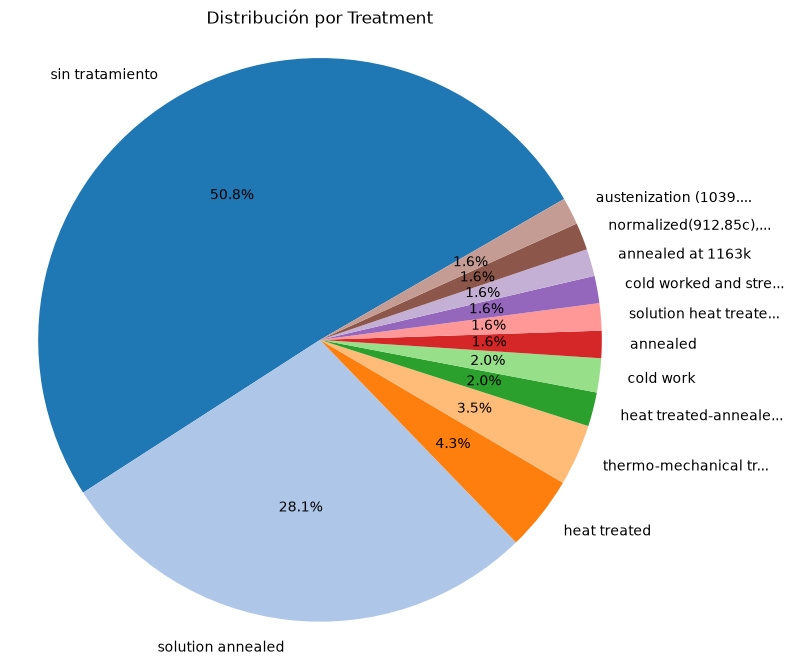

In [220]:
plt.figure(figsize=(8, 8))
treatment_counts = df['Treatment'].value_counts()
total = treatment_counts.sum()

# Separar en >= 1% y < 1%
mayores = treatment_counts[treatment_counts / total >= 0.01]
menores = treatment_counts[treatment_counts / total < 0.01]

# Unificar las menores en "Otros"
if len(menores) > 0:
    serie = pd.concat([mayores, pd.Series({'Otros': menores.sum()})])
else:
    serie = mayores

# Truncar etiquetas a 20 caracteres
etiquetas = [t[:20] + '...' if len(t) > 20 else t for t in serie.index]

colors = sns.color_palette('tab20', len(serie))
plt.pie(serie.values, 
        labels=etiquetas,
        autopct='%1.1f%%',
        colors=colors,
        startangle=30)

plt.title('Distribución por Treatment')
plt.axis('equal')
plt.show()

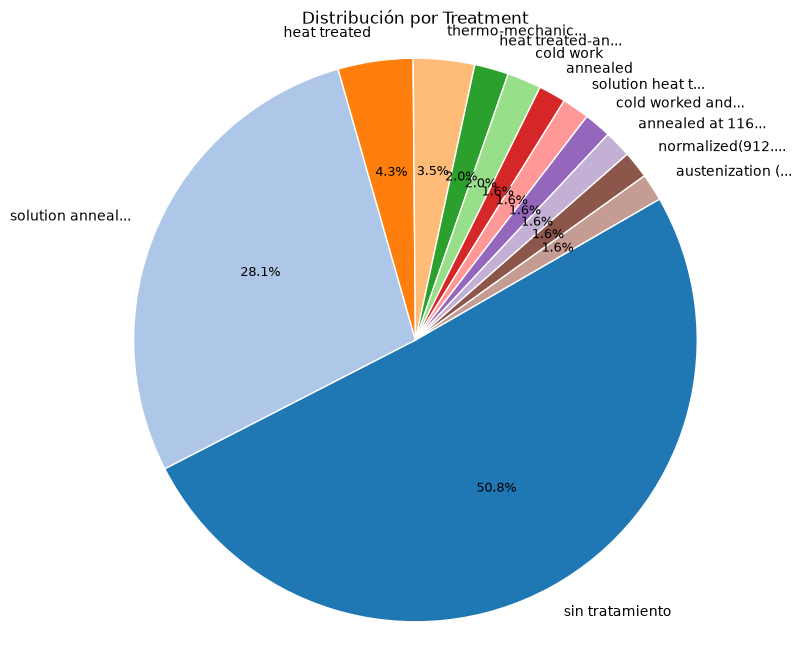

In [221]:
# Frecuencias relativas para Treatment
freq_rel = df['Treatment'].value_counts(normalize=True)

# Separar en >= 1% y < 1%
mayores = freq_rel[freq_rel >= 0.01]
menores = freq_rel[freq_rel < 0.01]

# Unificar las menores en "Otros"
data = mayores.copy()
if len(menores) > 0:
    data["Otros"] = menores.sum()

# Truncar etiquetas a 15 caracteres
labels = [label[:15] + '...' if len(label) > 15 else label for label in data.index]

colors = sns.color_palette('tab20', len(data))

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    data.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=30,
    counterclock=False,
    colors=colors,
    wedgeprops=dict(edgecolor='white')
)

for t in texts:
    t.set_fontsize(10)
for at in autotexts:
    at.set_fontsize(9)

plt.title('Distribución por Treatment')
plt.axis('equal')
plt.show()

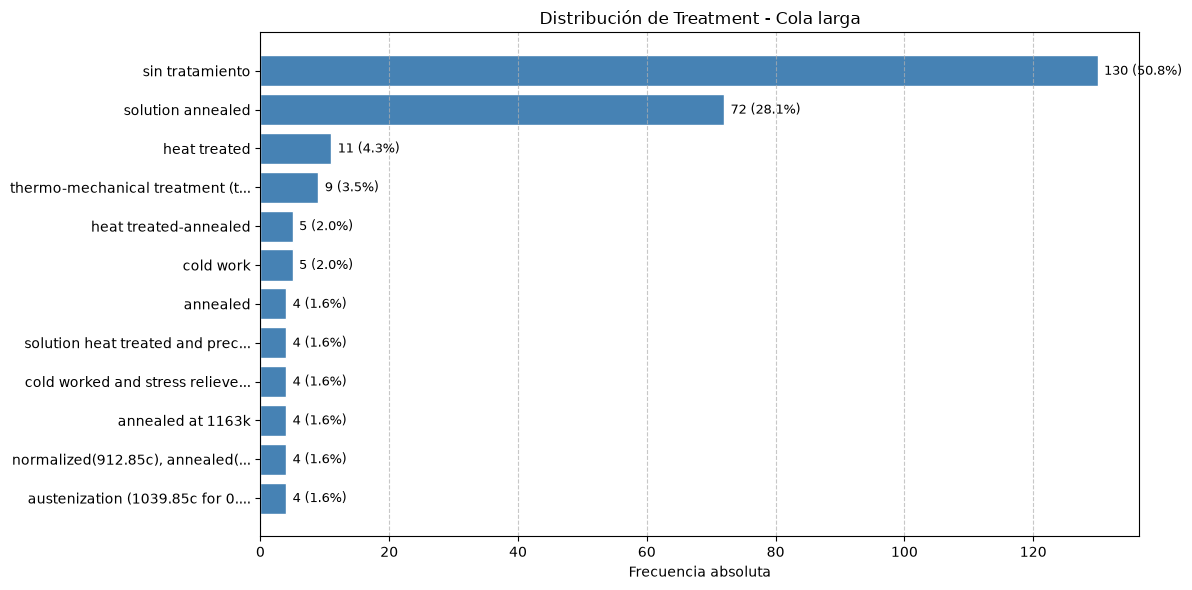

In [222]:
freq_abs = df['Treatment'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(freq_abs)), freq_abs.values, color='steelblue', edgecolor='white')

# Etiquetas truncadas en el eje Y
etiquetas = [t[:30] + '...' if len(t) > 30 else t for t in freq_abs.index]
ax.set_yticks(range(len(freq_abs)))
ax.set_yticklabels(etiquetas)

# Agregar valor y porcentaje en cada barra
total = freq_abs.sum()
for i, (v, pct) in enumerate(zip(freq_abs.values, freq_abs.values / total * 100)):
    ax.text(v + 1, i, f'{v} ({pct:.1f}%)', va='center', fontsize=9)

ax.set_xlabel('Frecuencia absoluta')
ax.set_title('Distribución de Treatment - Cola larga')
ax.invert_yaxis()  # La categoría más frecuente arriba
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [223]:
treatment_counts = df['Treatment'].value_counts() # Cuento ocurrencias de cada categoría
treatment_pi = treatment_counts / treatment_counts.sum() # Calculo las pi (frecuencias relativas)

# Entropía máxima (si todas las categorías ocurrieran con la misma probabilidad)
H_max = np.log2(df['Treatment'].nunique())

# Entropía de Shannon con Scipi
H_Shannon = entropy(treatment_pi, base=2)
print(f"Entropía H: {H_Shannon:.2f} - Entropia máxima H_max: {H_max:.2f}")

Entropía H: 2.16 - Entropia máxima H_max: 3.58


In [224]:
print(f"Cardinalidad: {df['Treatment'].nunique()}")
print(f"Frecuencias absolutas:\n{df['Treatment'].value_counts()}")
print(f"Frecuencias relativas:\n{df['Treatment'].value_counts(normalize=True).round(4)}")
print(f"Cardinalidad: {df['Treatment'].nunique()}")
print(f"Frecuencias absolutas:\n{df['Treatment'].value_counts()}")
print(f"Frecuencias relativas:\n{df['Treatment'].value_counts(normalize=True).round(4)}")

Cardinalidad: 12
Frecuencias absolutas:
Treatment
sin tratamiento                                                                                                                                                                             130
solution annealed                                                                                                                                                                            72
heat treated                                                                                                                                                                                 11
thermo-mechanical treatment (tmt)                                                                                                                                                             9
heat treated-annealed                                                                                                                                                                 

Un detalle importante antes de seguir: la variable Treatment está muy desbalanceada. Más de la mitad de las muestras (50.8%) están "sin tratamiento" y otro 28.1% son "solution annealed"; el resto se reparte entre muchas categorías con pocos casos (de 4 a 11 muestras). Por eso la entropía da 2.16 bits, bastante menos que el máximo posible de 3.58: la información está concentrada en unas pocas categorías. Esto hay que tenerlo en cuenta al comparar, porque en las categorías chicas hay muy poca muestra y cualquier promedio va a ser poco confiable.


---
### Resumen

#### Info General

Cardinalidad: 12
Cantidad de Observaciones Utiles: 256
Entropía: H = 2.16 bits / H_max = 3.58 bits → H/H_max = 60.3%


--- 
#### Estadística Descriptiva
---


In [225]:
# Estadisticas completas
def estadisticas_completas(data, columna):
    """Calcula medidas de tendencia central, dispersión y forma."""
    serie = data[columna].dropna()
    
    print(f"Estadísticas de '{columna}':")
    print(f"  Media:           {serie.mean():.2f}")
    print(f"  Mediana:         {serie.median():.2f}")
    print(f"  Moda:            {serie.mode()[0]:.2f}")
    print(f"  Varianza:        {serie.var():.2f}")
    print(f"  Desv. Estándar:  {serie.std():.2f}")
    print(f"  Asimetría:       {serie.skew():.2f}")
    print(f"  Curtosis:        {serie.kurtosis():.2f}")
    print(f"  Q1 (25%):        {serie.quantile(0.25):.2f}")
    print(f"  Q2 (50%):        {serie.quantile(0.50):.2f}")
    print(f"  Q3 (75%):        {serie.quantile(0.75):.2f}")
    print(f"  IQR:             {serie.quantile(0.75) - serie.quantile(0.25):.2f}")

In [226]:
estadisticas_completas(df, 'Yield Strength (MPa)')

Estadísticas de 'Yield Strength (MPa)':
  Media:           462.30
  Mediana:         472.86
  Moda:            103.00
  Varianza:        45918.30
  Desv. Estándar:  214.29
  Asimetría:       0.25
  Curtosis:        -0.02
  Q1 (25%):        268.60
  Q2 (50%):        472.86
  Q3 (75%):        605.50
  IQR:             336.90


In [227]:
estadisticas_completas(df, 'Ultimate Tensile Strength (MPa)')

Estadísticas de 'Ultimate Tensile Strength (MPa)':
  Media:           661.36
  Mediana:         625.25
  Moda:            684.00
  Varianza:        29632.84
  Desv. Estándar:  172.14
  Asimetría:       1.04
  Curtosis:        4.27
  Q1 (25%):        580.05
  Q2 (50%):        625.25
  Q3 (75%):        760.25
  IQR:             180.20


In [228]:
estadisticas_completas(df, 'Total Elongation (%)')

Estadísticas de 'Total Elongation (%)':
  Media:           34.29
  Mediana:         27.21
  Moda:            49.00
  Varianza:        493.96
  Desv. Estándar:  22.23
  Asimetría:       0.93
  Curtosis:        0.37
  Q1 (25%):        18.19
  Q2 (50%):        27.21
  Q3 (75%):        49.00
  IQR:             30.81


In [229]:
estadisticas_completas(df, 'Test Temperature (C)')

Estadísticas de 'Test Temperature (C)':
  Media:           104.55
  Mediana:         23.00
  Moda:            23.00
  Varianza:        35102.53
  Desv. Estándar:  187.36
  Asimetría:       1.87
  Curtosis:        2.35
  Q1 (25%):        23.00
  Q2 (50%):        23.00
  Q3 (75%):        23.00
  IQR:             0.00


In [230]:
estadisticas_completas(df, 'Fe (wt.%)')

Estadísticas de 'Fe (wt.%)':
  Media:           69.20
  Mediana:         67.66
  Moda:            64.94
  Varianza:        581.38
  Desv. Estándar:  24.11
  Asimetría:       -1.48
  Curtosis:        2.71
  Q1 (25%):        64.94
  Q2 (50%):        67.66
  Q3 (75%):        90.17
  IQR:             25.23


In [231]:
estadisticas_completas(df, 'C (wt.%)')

Estadísticas de 'C (wt.%)':
  Media:           0.07
  Mediana:         0.06
  Moda:            0.06
  Varianza:        0.00
  Desv. Estándar:  0.06
  Asimetría:       1.08
  Curtosis:        0.18
  Q1 (25%):        0.02
  Q2 (50%):        0.06
  Q3 (75%):        0.09
  IQR:             0.07


In [232]:
estadisticas_completas(df, 'Cr (wt.%)')

Estadísticas de 'Cr (wt.%)':
  Media:           11.15
  Mediana:         17.00
  Moda:            17.28
  Varianza:        64.74
  Desv. Estándar:  8.05
  Asimetría:       -0.54
  Curtosis:        -1.64
  Q1 (25%):        0.55
  Q2 (50%):        17.00
  Q3 (75%):        17.28
  IQR:             16.73


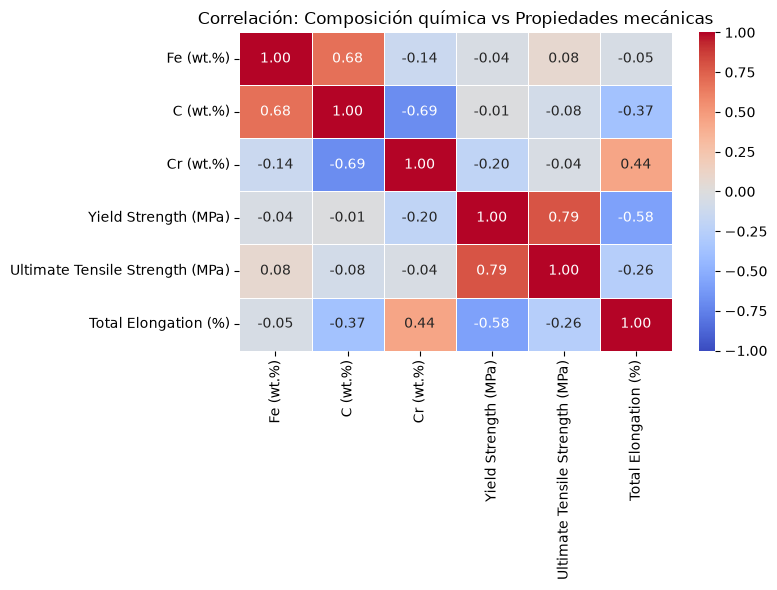

In [233]:
props_mec = ['Yield Strength (MPa)', 'Ultimate Tensile Strength (MPa)', 'Total Elongation (%)']
composicion = ['Fe (wt.%)', 'C (wt.%)', 'Cr (wt.%)']

# Matriz de correlación
corr_cols = composicion + props_mec
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlación: Composición química vs Propiedades mecánicas')
plt.tight_layout()
plt.show()

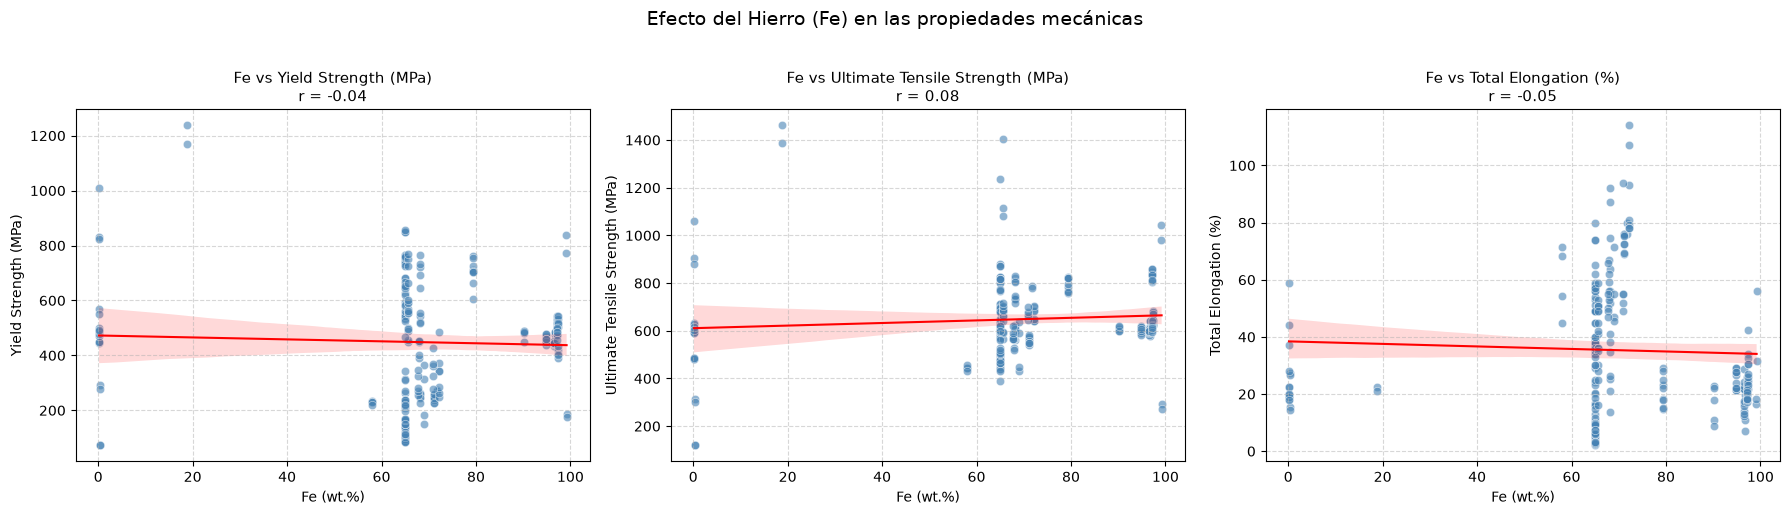

In [234]:
# --- Fe (wt.%) vs propiedades mecánicas ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for j, prop in enumerate(props_mec):
    ax = axes[j]
    sns.scatterplot(data=df, x='Fe (wt.%)', y=prop, ax=ax, alpha=0.6, color='steelblue')
    sns.regplot(data=df, x='Fe (wt.%)', y=prop, ax=ax, scatter=False, color='red', line_kws={'linewidth': 1.5})
    r = df['Fe (wt.%)'].corr(df[prop])
    ax.set_title(f'Fe vs {prop}\nr = {r:.2f}', fontsize=11)
    ax.set_xlabel('Fe (wt.%)')
    ax.set_ylabel(prop)
    ax.grid(axis='both', linestyle='--', alpha=0.5)

plt.suptitle('Efecto del Hierro (Fe) en las propiedades mecánicas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

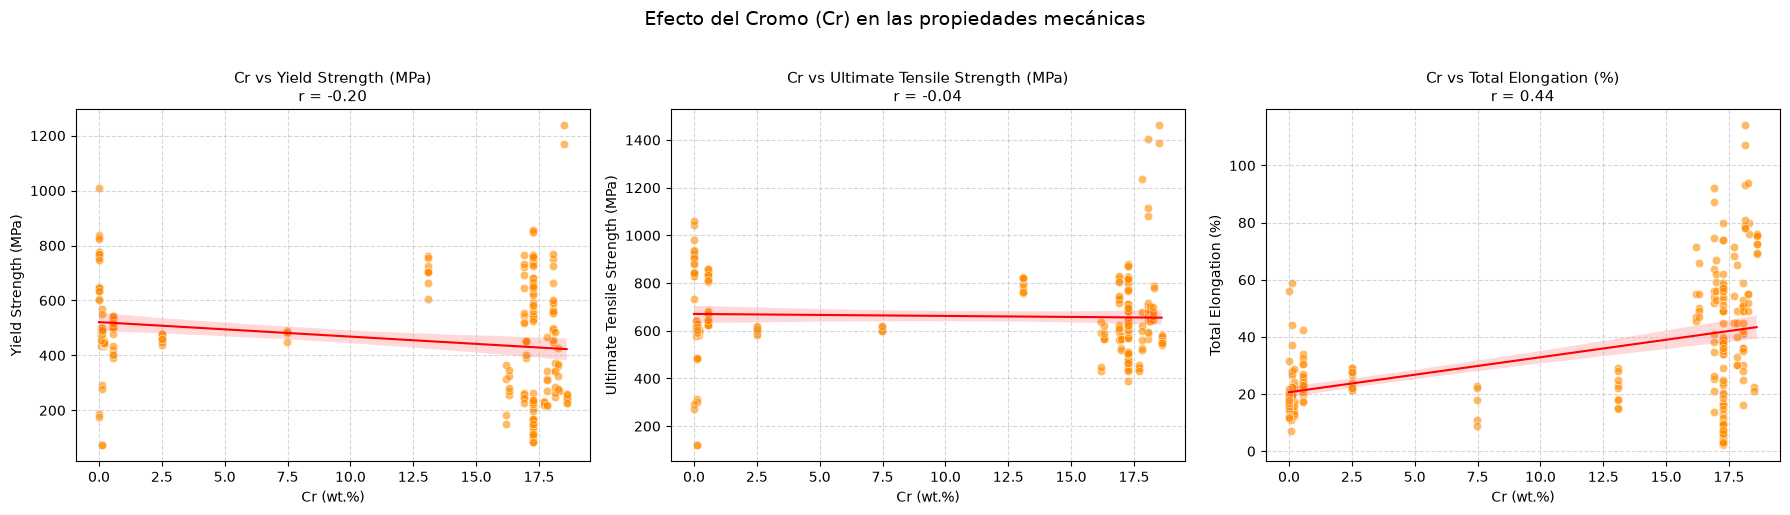

In [235]:
# --- Cr (wt.%) vs propiedades mecánicas ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for j, prop in enumerate(props_mec):
    ax = axes[j]
    sns.scatterplot(data=df, x='Cr (wt.%)', y=prop, ax=ax, alpha=0.6, color='darkorange')
    sns.regplot(data=df, x='Cr (wt.%)', y=prop, ax=ax, scatter=False, color='red', line_kws={'linewidth': 1.5})
    r = df['Cr (wt.%)'].corr(df[prop])
    ax.set_title(f'Cr vs {prop}\nr = {r:.2f}', fontsize=11)
    ax.set_xlabel('Cr (wt.%)')
    ax.set_ylabel(prop)
    ax.grid(axis='both', linestyle='--', alpha=0.5)

plt.suptitle('Efecto del Cromo (Cr) en las propiedades mecánicas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

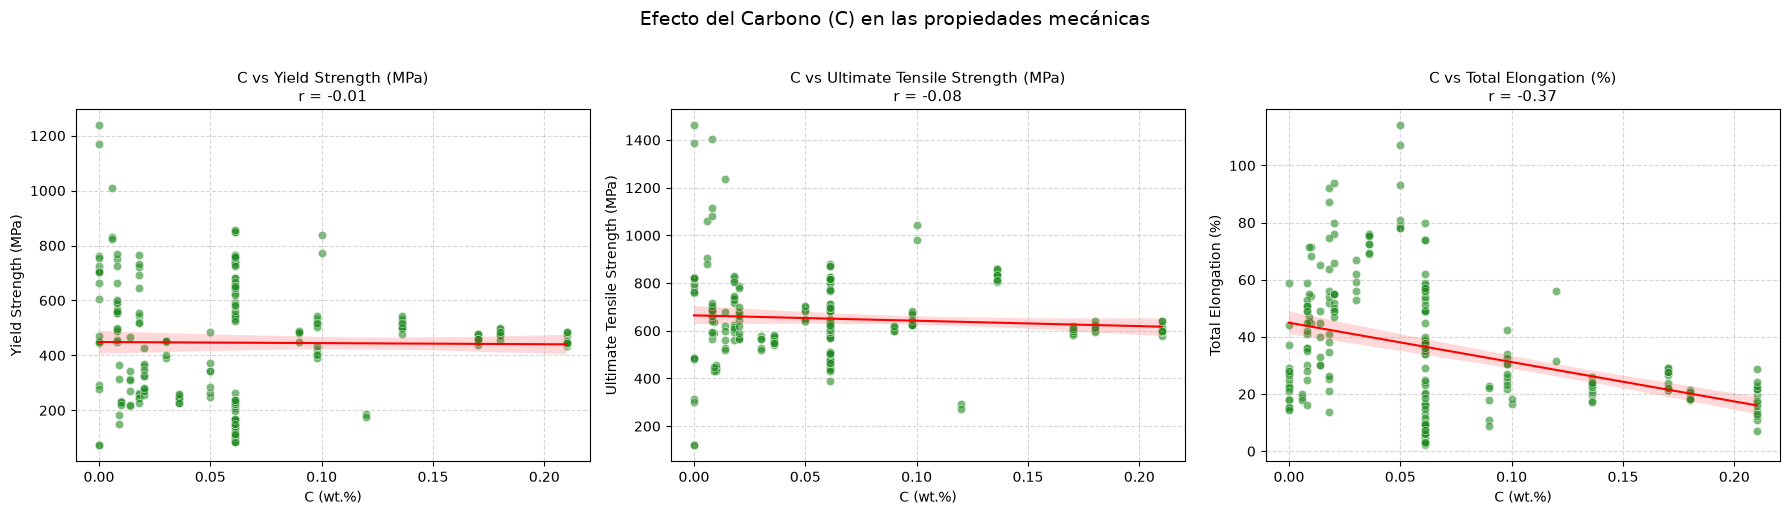

In [236]:
# --- C (wt.%) vs propiedades mecánicas ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for j, prop in enumerate(props_mec):
    ax = axes[j]
    sns.scatterplot(data=df, x='C (wt.%)', y=prop, ax=ax, alpha=0.6, color='forestgreen')
    sns.regplot(data=df, x='C (wt.%)', y=prop, ax=ax, scatter=False, color='red', line_kws={'linewidth': 1.5})
    r = df['C (wt.%)'].corr(df[prop])
    ax.set_title(f'C vs {prop}\nr = {r:.2f}', fontsize=11)
    ax.set_xlabel('C (wt.%)')
    ax.set_ylabel(prop)
    ax.grid(axis='both', linestyle='--', alpha=0.5)

plt.suptitle('Efecto del Carbono (C) en las propiedades mecánicas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Si miramos la correlación entre la composición y las propiedades, los valores son bastante bajos (en general |r| menor a 0.45). Lo más llamativo es la correlación positiva entre Cr y elongación (r ≈ 0.44) y la negativa entre C y elongación (r ≈ -0.37).


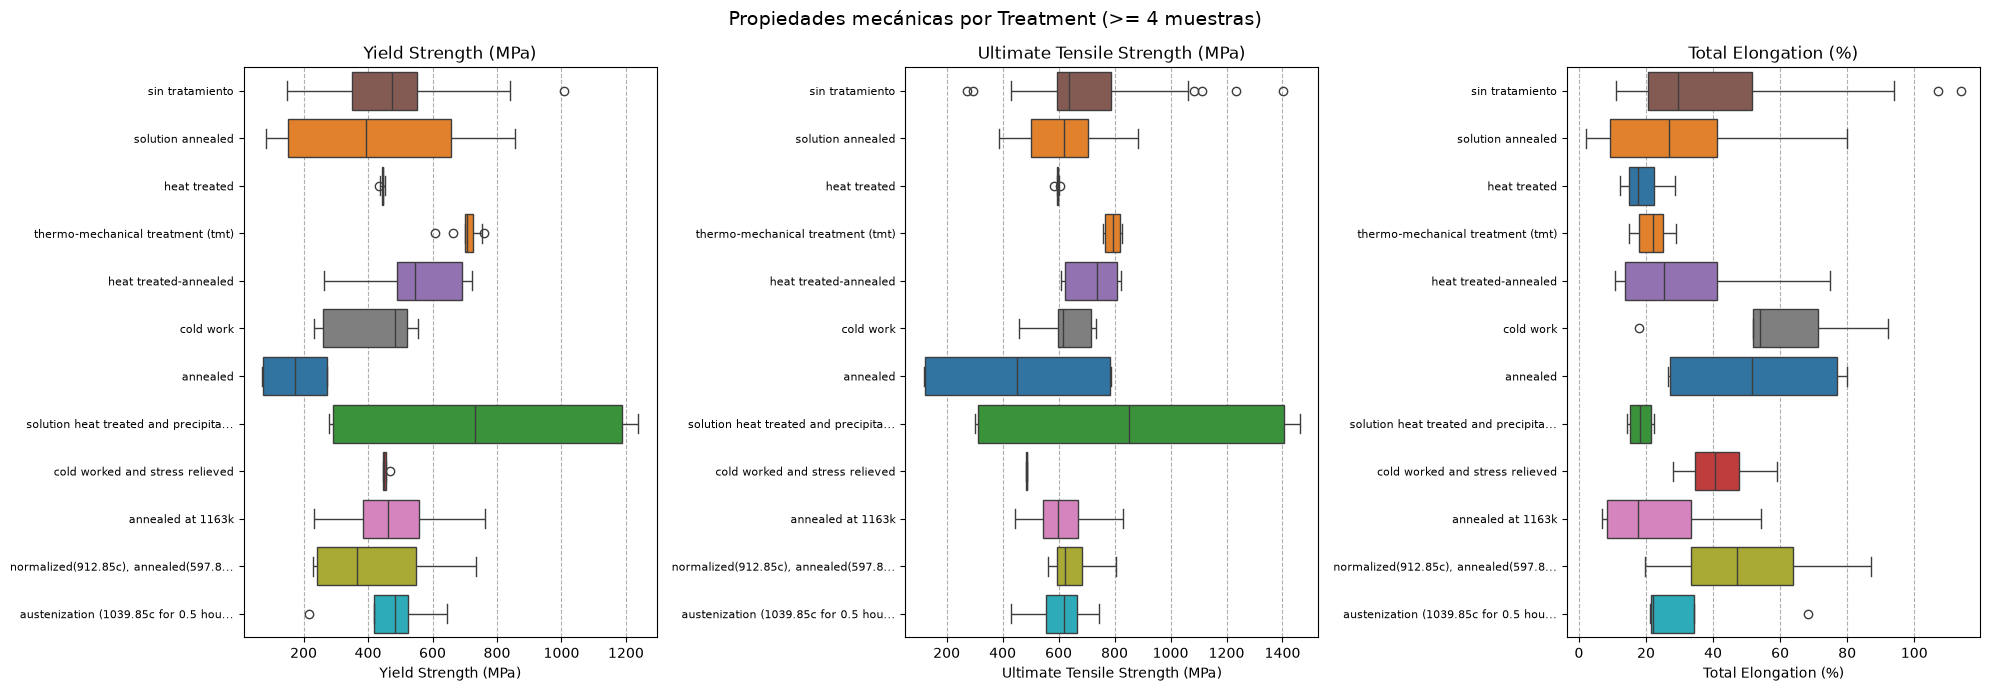

In [237]:
top_treatments = df['Treatment'].value_counts()
treatments_to_plot = top_treatments[top_treatments >= 4].index.tolist()
df_filtered = df[df['Treatment'].isin(treatments_to_plot)].copy()

# Truncar nombres largos para que entren en el gráfico
label_map = {t: (t[:35] + '...') if len(t) > 35 else t for t in treatments_to_plot}
df_filtered['Treatment_short'] = df_filtered['Treatment'].map(label_map)

# Ordenar por frecuencia para que el gráfico sea más legible
orden = df_filtered['Treatment_short'].value_counts().index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for i, prop in enumerate(props_mec):
    sns.boxplot(data=df_filtered, y='Treatment_short', x=prop, hue='Treatment_short',
                order=orden, palette='tab10', legend=False, ax=axes[i])
    axes[i].set_title(prop, fontsize=12)
    axes[i].grid(axis='x', linestyle='--')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='y', labelsize=8)  # Fuente más chica en etiquetas Y

plt.suptitle('Propiedades mecánicas por Treatment (>= 4 muestras)', fontsize=14)
plt.tight_layout()
plt.show()

In [238]:
media_trat = df_filtered.groupby('Treatment')[props_mec].mean().round(2)
print("Media de propiedades mecánicas por Treatment:")
print(media_trat)

Media de propiedades mecánicas por Treatment:
                                                    Yield Strength (MPa)  \
Treatment                                                                  
annealed                                                          172.75   
annealed at 1163k                                                 480.21   
austenization (1039.85c for 0.5 hour), then air...                457.34   
cold work                                                         409.41   
cold worked and stress relieved                                   453.25   
heat treated                                                      443.88   
heat treated-annealed                                             542.17   
normalized(912.85c), annealed(597.85c for 4 hou...                423.63   
sin tratamiento                                                   472.53   
solution annealed                                                 416.89   
solution heat treated and precipitation-ha

Mirando los boxplots y las medias por tratamiento se ve clarísimo el compromiso entre resistencia y ductilidad:
- Los tratamientos que más endurecen dan la resistencia más alta pero la elongación más baja. *Solution heat treated and precipitation-hardened* es el extremo: UTS ≈ 866 MPa con elongación ≈ 18%. Le sigue *thermo-mechanical treatment (tmt)* (UTS ≈ 795 MPa, elongación ≈ 21%, límite elástico ≈ 704 MPa).
- En el otro extremo, *annealed* tiene la resistencia más baja (UTS ≈ 453 MPa) pero la mejor ductilidad (elongación ≈ 52%).
- El "sin tratamiento" y el *solution annealed* quedan en el medio.

En resumen, el tratamiento no mejora ni empeora todo a la vez: desplaza el equilibrio entre resistencia y elongación. Si se necesita un material duro conviene uno de los tratamientos de endurecimiento; si se necesita que deforme bien antes de romperse, los recocidos.


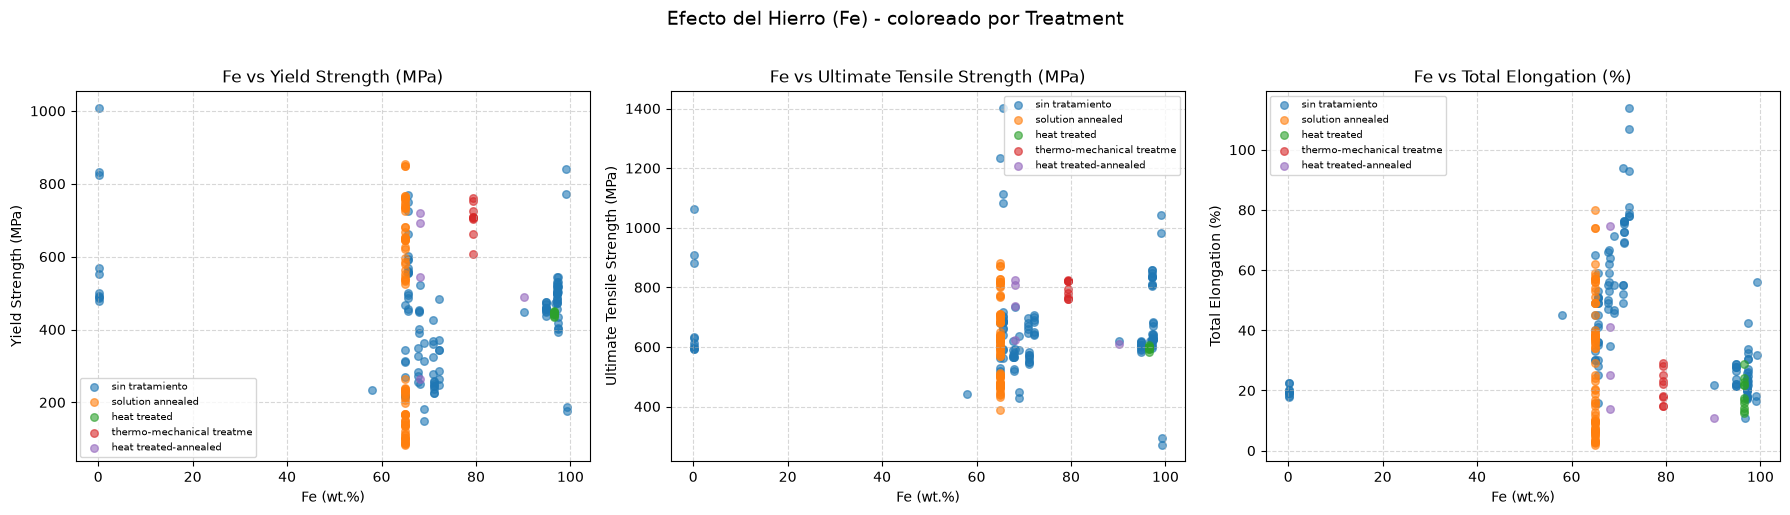

In [240]:
# --- Fe (wt.%) vs propiedades, coloreado por Treatment ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for j, prop in enumerate(props_mec):
    ax = axes[j]
    for treatment in treatments_to_plot[:5]:
        mask = df['Treatment'] == treatment
        ax.scatter(df.loc[mask, 'Fe (wt.%)'], df.loc[mask, prop],
                   alpha=0.6, label=treatment[:25], s=30)
    ax.set_xlabel('Fe (wt.%)')
    ax.set_ylabel(prop)
    ax.set_title(f'Fe vs {prop}')
    ax.legend(fontsize=7, loc='best')
    ax.grid(axis='both', linestyle='--', alpha=0.5)

plt.suptitle('Efecto del Hierro (Fe) - coloreado por Treatment', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

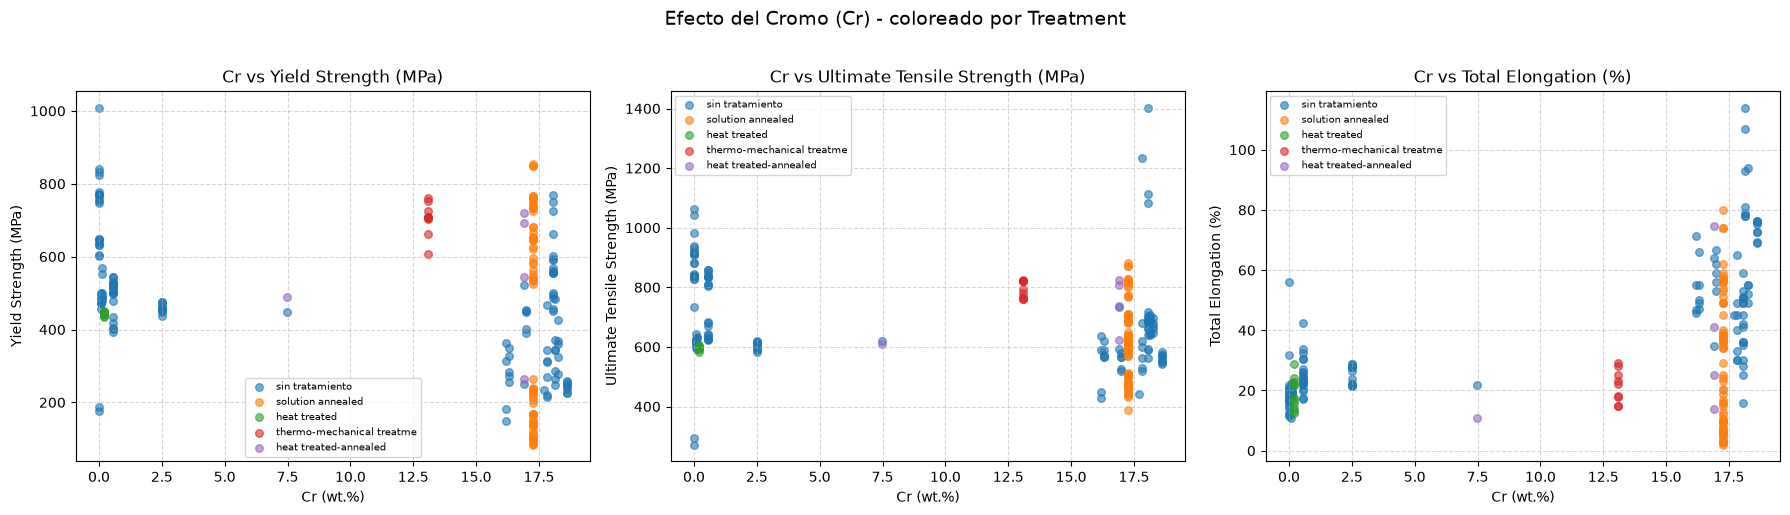

In [241]:
# --- Cr (wt.%) vs propiedades, coloreado por Treatment ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for j, prop in enumerate(props_mec):
    ax = axes[j]
    for treatment in treatments_to_plot[:5]:
        mask = df['Treatment'] == treatment
        ax.scatter(df.loc[mask, 'Cr (wt.%)'], df.loc[mask, prop],
                   alpha=0.6, label=treatment[:25], s=30)
    ax.set_xlabel('Cr (wt.%)')
    ax.set_ylabel(prop)
    ax.set_title(f'Cr vs {prop}')
    ax.legend(fontsize=7, loc='best')
    ax.grid(axis='both', linestyle='--', alpha=0.5)

plt.suptitle('Efecto del Cromo (Cr) - coloreado por Treatment', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

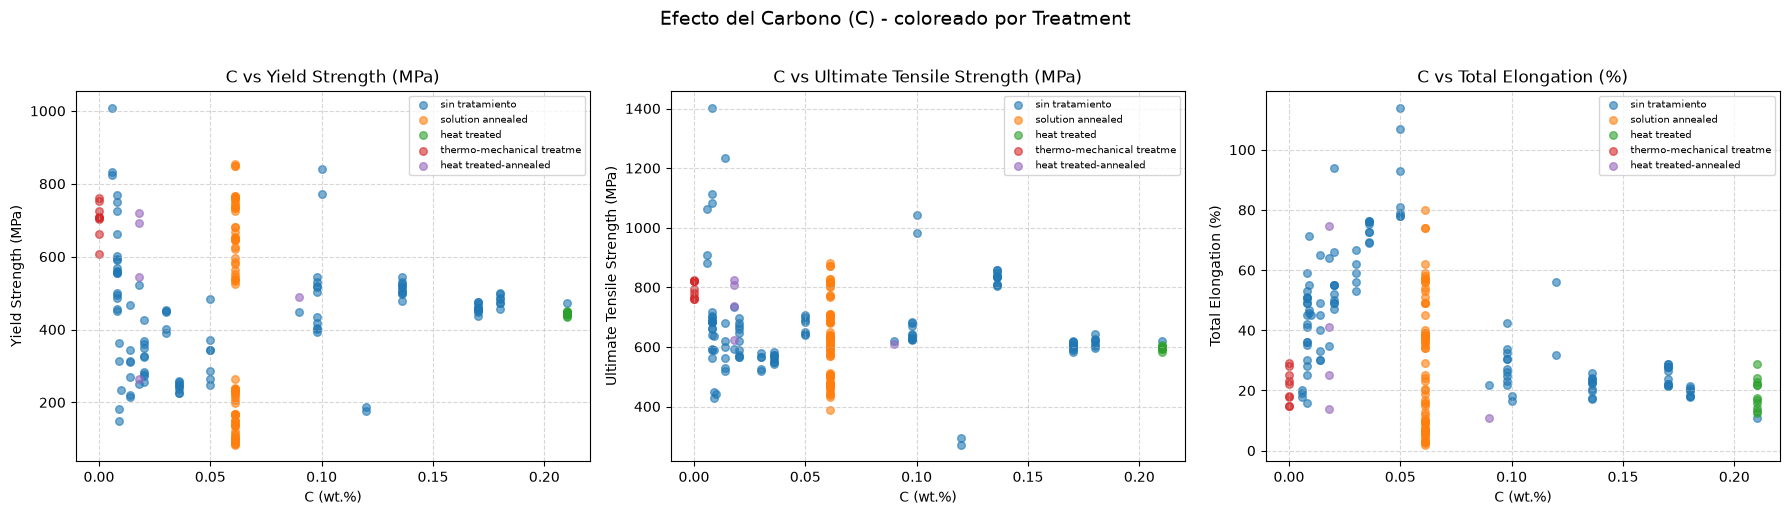

In [242]:
# --- C (wt.%) vs propiedades, coloreado por Treatment ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for j, prop in enumerate(props_mec):
    ax = axes[j]
    for treatment in treatments_to_plot[:5]:
        mask = df['Treatment'] == treatment
        ax.scatter(df.loc[mask, 'C (wt.%)'], df.loc[mask, prop],
                   alpha=0.6, label=treatment[:25], s=30)
    ax.set_xlabel('C (wt.%)')
    ax.set_ylabel(prop)
    ax.set_title(f'C vs {prop}')
    ax.legend(fontsize=7, loc='best')
    ax.grid(axis='both', linestyle='--', alpha=0.5)

plt.suptitle('Efecto del Carbono (C) - coloreado por Treatment', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

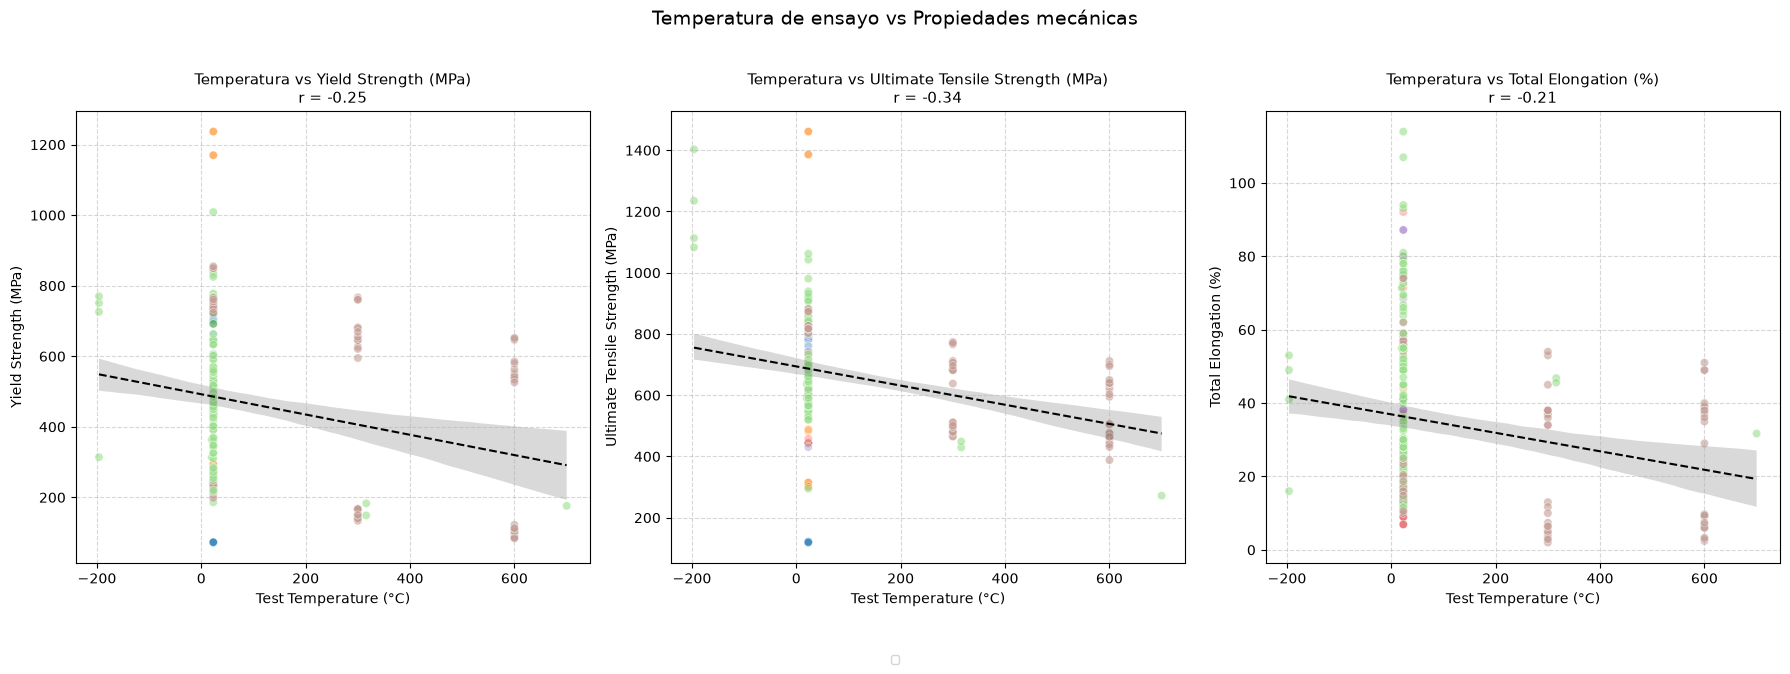

In [243]:
# --- 7. Test Temperature vs Propiedades (para ver el efecto de la temperatura) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, prop in enumerate(props_mec):
    ax = axes[i]
    sns.scatterplot(data=df, x='Test Temperature (C)', y=prop,
                    hue='Treatment', alpha=0.6, ax=ax, palette='tab20',
                    legend=False)  # Ocultamos la leyenda completa
    sns.regplot(data=df, x='Test Temperature (C)', y=prop,
                scatter=False, ax=ax, color='black', line_kws={'linewidth': 1.5, 'linestyle': '--'})
    r = df['Test Temperature (C)'].corr(df[prop])
    ax.set_title(f'Temperatura vs {prop}\nr = {r:.2f}', fontsize=11)
    ax.set_xlabel('Test Temperature (°C)')
    ax.set_ylabel(prop)
    ax.grid(axis='both', linestyle='--', alpha=0.5)

plt.suptitle('Temperatura de ensayo vs Propiedades mecánicas', fontsize=14, y=1.02)

# Leyenda única fuera de los gráficos
handles, labels = ax.get_legend_handles_labels()
# Truncar labels para la leyenda
labels_trunc = [l[:30] + '...' if len(l) > 30 else l for l in labels]
fig.legend(handles, labels_trunc, loc='lower center', ncol=3, fontsize=8,
           bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.show()

La temperatura de ensayo. La mayoría de las pruebas se hicieron a 23°C, pero hay corridas a muy baja (-196°C) y a alta (hasta 700°C) temperatura. La correlación con las propiedades es negativa (r ≈ -0.2 a -0.35), o sea que a mayor temperatura de ensayo las propiedades tienden a bajar. Vale aclararlo para no atribuir al tratamiento diferencias que en realidad vienen de ensayar a temperaturas distintas.


In [ ]:
def detectar_outliers_iqr(data, columna):
    """Detecta outliers usando el método IQR."""
    serie = data[columna].dropna()
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = serie[(serie < limite_inferior) | (serie > limite_superior)]
    
    print(f"--- {columna} ---")
    print(f"  Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
    print(f"  Límite inferior: {limite_inferior:.2f}")
    print(f"  Límite superior: {limite_superior:.2f}")
    print(f"  Outliers detectados: {len(outliers)} ({len(outliers)/len(serie)*100:.1f}%)")
    if len(outliers) > 0:

        print(f"  Valores outliers: {sorted(outliers.tolist())}")
    print()
    
    return outliers, limite_inferior, limite_superior

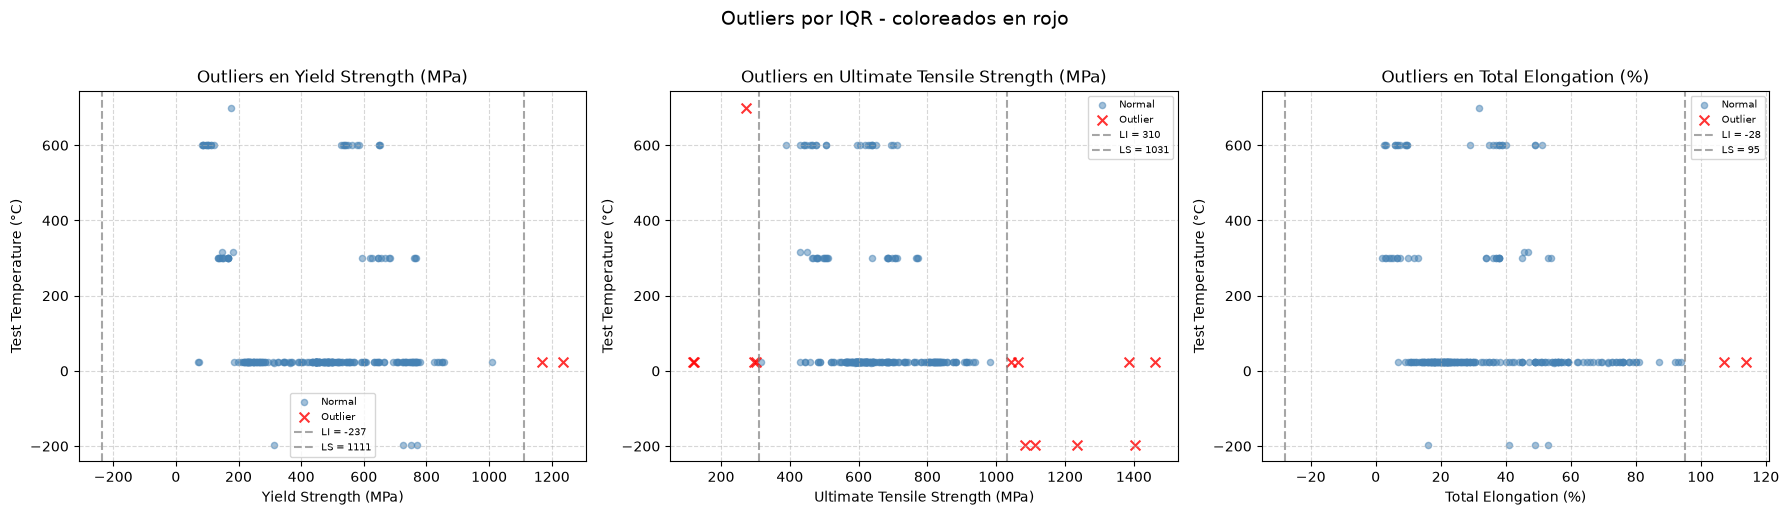

In [ ]:
# Outliers coloreados por Treatment ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for j, prop in enumerate(props_mec):
    ax = axes[j]
    li = outliers_iqr[prop]['LI']
    ls = outliers_iqr[prop]['LS']
    
    # Puntos normales
    mask_normal = (df[prop] >= li) & (df[prop] <= ls)
    ax.scatter(df.loc[mask_normal, prop], 
               df.loc[mask_normal, 'Test Temperature (C)'],
               alpha=0.5, color='steelblue', s=20, label='Normal')
    
    # Puntos outlier
    mask_outlier = ~mask_normal
    ax.scatter(df.loc[mask_outlier, prop],
               df.loc[mask_outlier, 'Test Temperature (C)'],
               alpha=0.8, color='red', s=50, marker='x', label='Outlier')
    
    # Límites
    ax.axvline(x=li, color='gray', linestyle='--', alpha=0.7, label=f'LI = {li:.0f}')
    ax.axvline(x=ls, color='gray', linestyle='--', alpha=0.7, label=f'LS = {ls:.0f}')
    
    ax.set_xlabel(prop)
    ax.set_ylabel('Test Temperature (°C)')
    ax.set_title(f'Outliers en {prop}')
    ax.legend(fontsize=7, loc='best')
    ax.grid(axis='both', linestyle='--', alpha=0.5)

plt.suptitle('Outliers por IQR - coloreados en rojo', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
### Análisis de outliers
---

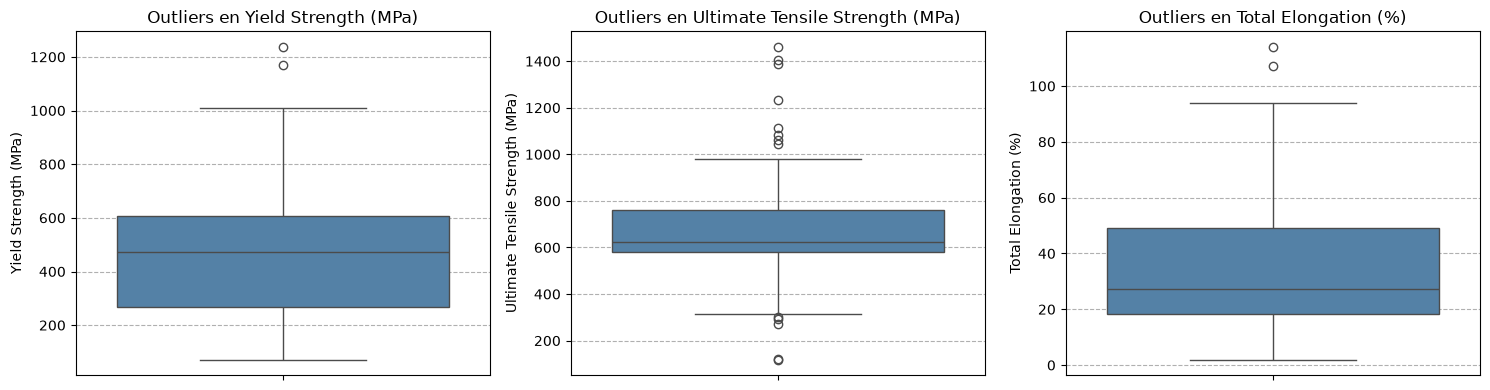

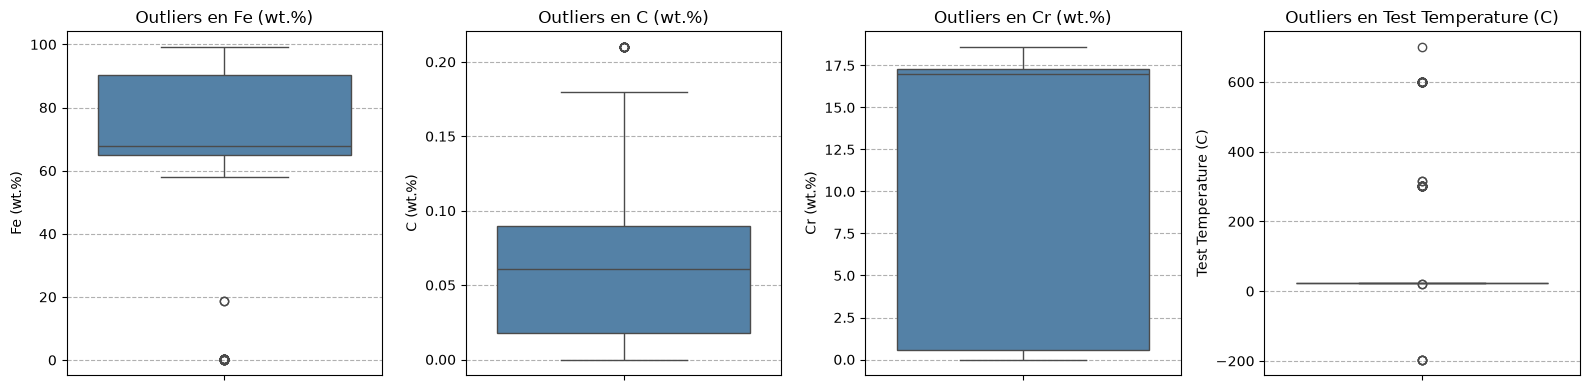

In [246]:
# ============================================================
# Boxplots individuales por propiedad mecánica
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, prop in enumerate(props_mec):
    sns.boxplot(y=df[prop], ax=axes[i], color='steelblue')
    axes[i].set_title(f'Outliers en {prop}')
    axes[i].grid(axis='y', ls='--')

plt.tight_layout()
plt.show()

# También para composición y temperatura
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, var in enumerate(composicion + ['Test Temperature (C)']):
    sns.boxplot(y=df[var], ax=axes[i], color='steelblue')
    axes[i].set_title(f'Outliers en {var}')
    axes[i].grid(axis='y', ls='--')

plt.tight_layout()
plt.show()

In [253]:
print("Investigación de outliers por Treatment (IQR en props_mec)")
print("=" * 65)

for prop in props_mec:
    li = outliers_iqr[prop]['LI']
    ls = outliers_iqr[prop]['LS']
    outlier_idx = df[(df[prop] < li) | (df[prop] > ls)].index
    
    if len(outlier_idx) == 0:
        continue
    
    print(f"\n--- {prop} ---")
    print(f"  Límites IQR: [{li:.2f}, {ls:.2f}]")
    print(f"  Outliers: {len(outlier_idx)} muestras")
    
    # ¿Qué treatments?
    trat_counts = df.loc[outlier_idx, 'Treatment'].value_counts()
    print(f"  Treatment de los outliers:")
    for trat, count in trat_counts.items():
        total_trat = (df['Treatment'] == trat).sum()
        print(f"    {trat}: {count} de {total_trat} muestras ({count/total_trat*100:.0f}%)")
    
    # ¿Qué temperatura de ensayo?
    temp_vals = df.loc[outlier_idx, 'Test Temperature (C)']
    print(f"  Temperatura de ensayo: {sorted(temp_vals.unique().tolist())}")
    
    # ¿Son los más extremos de su Treatment?
    print(f"  Valores: {sorted(df.loc[outlier_idx, prop].tolist())}")


Investigación de outliers por Treatment (IQR en props_mec)

--- Yield Strength (MPa) ---
  Límites IQR: [-236.76, 1110.85]
  Outliers: 2 muestras
  Treatment de los outliers:
    solution heat treated and precipitation-hardened: 2 de 4 muestras (50%)
  Temperatura de ensayo: [23.0]
  Valores: [1170.0, 1237.0]

--- Ultimate Tensile Strength (MPa) ---
  Límites IQR: [309.76, 1030.55]
  Outliers: 13 muestras
  Treatment de los outliers:
    sin tratamiento: 8 de 130 muestras (6%)
    solution heat treated and precipitation-hardened: 3 de 4 muestras (75%)
    annealed: 2 de 4 muestras (50%)
  Temperatura de ensayo: [-196.0, 23.0, 700.0]
  Valores: [119.0, 122.0, 272.0, 295.0, 301.0, 1042.7, 1062.0, 1083.0, 1113.0, 1235.0, 1386.0, 1403.0, 1461.0]

--- Total Elongation (%) ---
  Límites IQR: [-28.02, 95.21]
  Outliers: 2 muestras
  Treatment de los outliers:
    sin tratamiento: 2 de 130 muestras (2%)
  Temperatura de ensayo: [23.0]
  Valores: [107.0, 114.0]
